## Reto de la semana 4
Diego Andrés Burbano A.

In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize
from google.colab import drive, files

%matplotlib inline

In [20]:
# Montaje del drive
drive.mount('/content/drive', force_remount=True)
os.chdir('/content/drive/MyDrive/datos')

data = pd.read_csv('./BreastCancer.csv', sep=',')

Mounted at /content/drive


In [21]:
data.head()

,radius_mean,smoothness_mean,pronostic
0,0.950308,1.523620,1
1,1.646970,-0.893636,1
2,1.409349,0.891658,1
3,-0.823748,3.254336,1
4,1.571363,0.223788,1


In [22]:
data.shape

(469, 3)

In [35]:
# a) Definir la función para calcular f(w)
def calcular_f(w, data):
    X = data.iloc[:, :-1].values
    t = data.iloc[:, -1].values
    m = len(t)
    f_w = 0
    for i in range(m):
        z_i = np.append(X[i], 1)
        y_i = 1 / (1 + np.exp(-np.dot(w, z_i)))
        f_w += t[i] * np.log(y_i) + (1 - t[i]) * np.log(1 - y_i)

    f_w = -f_w / m
    return f_w

# Definimos los límites:
boundaries = [(None, None), (None, None), (None, None)]

# Condiciones iniciales
x0 = [0, 0, 0]

# Ejecutamos minimize sin restricciones
res = minimize(calcular_f, x0, args=(data,), bounds=boundaries)

print(res)


  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.20464127038690735
        x: [ 5.359e+00  1.641e+00  2.444e-01]
      nit: 12
      jac: [ 1.332e-07 -8.049e-08 -1.388e-08]
     nfev: 56
     njev: 14
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


In [29]:
# Definición de variable mejor_w como el mejor w (optimizado)
mejor_w = res.x

# Función para dibujar las rectas
def plot_lines(w):
  x_vals = np.linspace(data['radius_mean'].min(), data['radius_mean'].max(), 400)
  y_vals = -(w[0] * x_vals + w[2]) / w[1]
  plt.plot(x_vals, y_vals, label='Frontera de decisión', color='black', linestyle='--')
  return

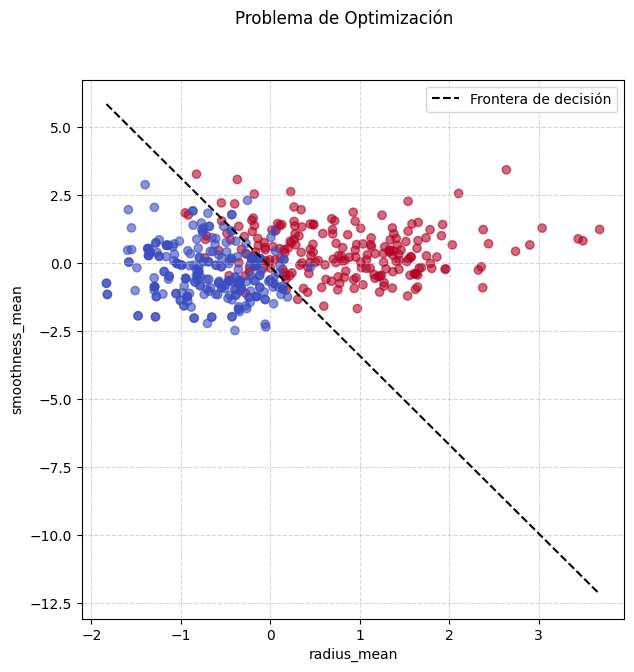

In [33]:
# Función para dibujar los puntos de data (gráfico scatter)
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111)
ax.scatter(data['radius_mean'], data['smoothness_mean'], c=data['pronostic'], cmap = 'coolwarm', alpha = 0.6)
plot_lines(mejor_w)

ax.set_xlabel('radius_mean')
ax.set_ylabel('smoothness_mean')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
fig.suptitle('Problema de Optimización')
plt.show()

In [26]:
# Calcular f(w) para el vector w encontrado
f_mejorw = calcular_f(mejor_w, data)
print(f_mejorw)

0.20464127038690735


In [27]:
def calcular_gradiente_y_hessiana(w, data):
    # Extraer características y etiquetas
    X = data.iloc[:, :-1].values
    t = data.iloc[:, -1].values

    m = len(t)
    n = len(w)
    grad = np.zeros(n)
    hess = np.zeros((n, n))

    for i in range(m):
        z_i = np.append(X[i], 1)
        y_i = 1 / (1 + np.exp(-np.dot(w, z_i)))
        y_i = np.clip(y_i, 1e-15, 1 - 1e-15)

        # Gradiente
        grad += (y_i - t[i]) * z_i

        # Hessiana
        hess += y_i * (1 - y_i) * np.outer(z_i, z_i)

    grad = grad / m
    hess = hess / m

    return grad, hess

In [34]:
grad, hess = calcular_gradiente_y_hessiana(mejor_w, data)
print("Gradiente mejor w encontrado:\n", grad)
print("Hessiana mejor w encontrado:\n", hess)

Gradiente mejor w encontrado:
 [ 1.32111952e-07 -6.61893471e-08  1.31362700e-08]
Hessiana mejor w encontrado:
 [[ 0.01005922 -0.01356702 -0.01039308]
 [-0.01356702  0.05477348  0.00994813]
 [-0.01039308  0.00994813  0.06329683]]
